# Respiratory Sound Classification Pipeline (ICBHI / Respiratory Sound Database)

This notebook implements an end-to-end pipeline:

1. **Load labels** from `patient_diagnosis.csv`
2. **Extract audio features** (MFCC, Chroma, Spectral Contrast, ZCR, Centroid, Rolloff, RMS, Duration)
3. **Clean labels** (drop rare classes)
4. **Train/test split** (stratified)
5. **Scale features** (StandardScaler)
6. **Balance training set** (SMOTE if available) *or* use **class weights**
7. **Train multiple models** (RF, Logistic Regression, SVM, MLP,  XGBoost)
8. **Evaluate** (Accuracy, Macro-F1, Macro ROC-AUC) + Confusion Matrix
9. **Save artifacts** (models, scaler, label encoder, CSV summaries)
10. **Generate figures** for the paper (waveform, Mel-spectrogram, MFCC, class distribution, model comparison, confusion matrix, feature importance)



## 0) Imports & Setup

- **Required**: `librosa`, `numpy`, `pandas`, `scikit-learn`, `matplotlib`, `seaborn`
- **Optional**:
  - `imblearn` for **SMOTE**
  - `xgboost` for **XGBoost**

If you don’t have optional libraries, the notebook still runs (it just skips them).

In [ ]:
import os
import random

import numpy as np
import pandas as pd

import librosa
import librosa.display

from collections import Counter

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score,
    roc_auc_score
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

from imblearn.over_sampling import SMOTE
import xgboost as xgb

import joblib
import matplotlib.pyplot as plt
import seaborn as sns

random.seed(42)
np.random.seed(42)


SMOTE available: True
XGBoost available: True


## 1) User Configuration


- `DATASET_PATH`: folder containing WAV files
- `DIAGNOSIS_CSV`: path to `patient_diagnosis.csv`

All outputs will be saved in `SAVE_MODELS_DIR`.

In [ ]:
DATASET_PATH = r"D:\gradution project\ICBHI_final_database"

DIAGNOSIS_CSV = r"D:\gradution project\Respiratory_Sound_Database\Respiratory_Sound_Database\patient_diagnosis.csv"

FEATURES_CSV = os.path.join(DATASET_PATH, "audio_features.csv")

MIN_SAMPLES_PER_CLASS = 3
TEST_SIZE = 0.20
RANDOM_STATE = 42

USE_SMOTE = True

SAVE_MODELS_DIR = r"D:\gradution project\models\m4"
os.makedirs(SAVE_MODELS_DIR, exist_ok=True)

print("DATASET_PATH:", DATASET_PATH)
print("DIAGNOSIS_CSV:", DIAGNOSIS_CSV)
print("FEATURES_CSV:", FEATURES_CSV)
print("SAVE_MODELS_DIR:", SAVE_MODELS_DIR)


DATASET_PATH: D:\gradution project\ICBHI_final_database
DIAGNOSIS_CSV: D:\gradution project\Respiratory_Sound_Database\Respiratory_Sound_Database\patient_diagnosis.csv
FEATURES_CSV: D:\gradution project\ICBHI_final_database\audio_features.csv
SAVE_MODELS_DIR: D:\gradution project\models\m4


## 2) Feature Extraction

We compute:

- MFCC (mean & std)
- Chroma (mean & std)
- Spectral Contrast (mean & std)
- ZCR (mean & std)
- Spectral Centroid (mean & std)
- Spectral Rolloff (mean & std)
- RMS (mean & std)
- Duration

In [ ]:
def extract_features_file(wav_path, sr=22050, n_mfcc=13):
    y, sr = librosa.load(wav_path, sr=sr)
    if y is None or len(y) == 0:
        return None

    duration = librosa.get_duration(y=y, sr=sr)

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    mfcc_mean = np.mean(mfcc, axis=1)
    mfcc_std  = np.std(mfcc, axis=1)

    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    chroma_mean = np.mean(chroma, axis=1)
    chroma_std  = np.std(chroma, axis=1)

    spec_contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
    sc_mean = np.mean(spec_contrast, axis=1)
    sc_std  = np.std(spec_contrast, axis=1)

    zcr = librosa.feature.zero_crossing_rate(y)
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    rms = librosa.feature.rms(y=y)

    feats = np.hstack([
        mfcc_mean, mfcc_std,
        chroma_mean, chroma_std,
        sc_mean, sc_std,
        np.mean(zcr), np.std(zcr),
        np.mean(centroid), np.std(centroid),
        np.mean(rolloff), np.std(rolloff),
        np.mean(rms), np.std(rms),
        duration
    ])
    return feats

## 3) Build Dataset (Load cached features or extract)

This creates:

- `X` (features)
- `labels` (string diagnosis)
- `filenames`

In [4]:
print("Loading diagnosis CSV...")
df = pd.read_csv(DIAGNOSIS_CSV)
if len(df.columns) < 2:
    raise ValueError("Diagnosis CSV must contain at least two columns: patient_id and diagnosis")

df = df.iloc[:, :2].copy()
df.columns = ["patient_id", "diagnosis"]
df["patient_id"] = pd.to_numeric(df["patient_id"], errors="coerce").astype("Int64")

print("Diagnosis entries:", len(df))

wav_files = sorted([f for f in os.listdir(DATASET_PATH) if f.lower().endswith(".wav")])
print("WAV files found:", len(wav_files))

if os.path.exists(FEATURES_CSV):
    print("Loading cached features:", FEATURES_CSV)
    df_feat = pd.read_csv(FEATURES_CSV, index_col=0)
    X = df_feat.drop(columns=["label"]).values
    labels = df_feat["label"].values
    filenames = df_feat.index.to_list()
else:
    print("Extracting features (this can take time)...")
    feats_list, labels, filenames = [], [], []

    for i, f in enumerate(wav_files, 1):
        wav_path = os.path.join(DATASET_PATH, f)

        token = f.split("_")[0]
        digits = "".join([c for c in token if c.isdigit()])
        if digits == "":
            continue
        pid = int(digits)

        row = df[df["patient_id"] == pid]
        if row.empty:
            continue

        label = row["diagnosis"].values[0]
        feat = extract_features_file(wav_path)
        if feat is None:
            continue

        feats_list.append(feat)
        labels.append(label)
        filenames.append(f)

        if i % 200 == 0:
            print(f"Processed {i}/{len(wav_files)} files...")

    X = np.vstack(feats_list)
    labels = np.array(labels)
    filenames = np.array(filenames)

    # Build feature names (to keep feature CSV readable)
    col_names = []
    n_mfcc = 13
    col_names += [f"mfcc_mean_{i+1}" for i in range(n_mfcc)]
    col_names += [f"mfcc_std_{i+1}" for i in range(n_mfcc)]
    col_names += [f"chroma_mean_{i+1}" for i in range(12)]
    col_names += [f"chroma_std_{i+1}" for i in range(12)]
    col_names += [f"sc_mean_{i+1}" for i in range(7)]
    col_names += [f"sc_std_{i+1}" for i in range(7)]
    col_names += [
        "zcr_mean","zcr_std",
        "centroid_mean","centroid_std",
        "rolloff_mean","rolloff_std",
        "rms_mean","rms_std",
        "duration"
    ]

    df_feat = pd.DataFrame(X, columns=col_names, index=filenames)
    df_feat["label"] = labels
    df_feat.to_csv(FEATURES_CSV)
    print("Saved cached features to:", FEATURES_CSV)

print("Total samples:", X.shape[0])
print("Label distribution (raw):")
print(Counter(labels))

Loading diagnosis CSV...
Diagnosis entries: 125
WAV files found: 920
Loading cached features: D:\gradution project\ICBHI_final_database\audio_features.csv
Total samples: 918
Label distribution (raw):
Counter({'COPD': 793, 'Pneumonia': 37, 'Healthy': 35, 'URTI': 21, 'Bronchiectasis': 16, 'Bronchiolitis': 13, 'LRTI': 2, 'Asthma': 1})


## 4) Remove Rare Classes + Encode Labels

We drop classes with fewer than `MIN_SAMPLES_PER_CLASS` samples, then re-encode labels.

In [5]:
le = LabelEncoder()
y_all = le.fit_transform(labels)

classes, counts = np.unique(y_all, return_counts=True)
valid_classes = [c for c, n in zip(classes, counts) if n >= MIN_SAMPLES_PER_CLASS]

mask = np.isin(y_all, valid_classes)
X = X[mask]
labels = np.array(labels)[mask]
filenames = np.array(filenames)[mask]

y_all = le.fit_transform(labels)

print(f"After dropping rare classes (<{MIN_SAMPLES_PER_CLASS} samples):")
print(Counter(labels))
print("Number of classes:", len(le.classes_))

After dropping rare classes (<3 samples):
Counter({'COPD': 793, 'Pneumonia': 37, 'Healthy': 35, 'URTI': 21, 'Bronchiectasis': 16, 'Bronchiolitis': 13})
Number of classes: 6


## 5) Train/Test Split + Scaling

- Stratified split
- Fit scaler on train only

In [6]:
X_train, X_test, y_train, y_test, fn_train, fn_test = train_test_split(
    X, y_all, filenames,
    test_size=TEST_SIZE,
    stratify=y_all,
    random_state=RANDOM_STATE
)

print("Train size:", X_train.shape[0], " Test size:", X_test.shape[0])
print("Train distribution:", Counter(y_train))

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

Train size: 732  Test size: 183
Train distribution: Counter({2: 634, 4: 30, 3: 28, 5: 17, 0: 13, 1: 10})


## 6) Balance the Training Set (SMOTE or Weights)

- If SMOTE exists and enabled: balance training set using SMOTE
- Else: keep original and use **sample weights**

In [7]:
use_smote = USE_SMOTE and HAVE_SMOTE
if use_smote:
    print("Using SMOTE on training set...")
    sm = SMOTE(random_state=RANDOM_STATE)
    X_train_bal, y_train_bal = sm.fit_resample(X_train_scaled, y_train)
    print("After SMOTE distribution:", Counter(y_train_bal))
else:
    print("SMOTE disabled or not installed -> using sample weights.")
    X_train_bal, y_train_bal = X_train_scaled, y_train

cw = class_weight.compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_bal),
    y=y_train_bal
)
class_weights_dict = {cls: w for cls, w in zip(np.unique(y_train_bal), cw)}
sample_weights = np.array([class_weights_dict[c] for c in y_train_bal])

print("Example class_weights_dict:", dict(list(class_weights_dict.items())[:5]))

Using SMOTE on training set...
After SMOTE distribution: Counter({3: 634, 2: 634, 1: 634, 5: 634, 4: 634, 0: 634})
Example class_weights_dict: {0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0}


## 7) Define Models

We compare several classifiers. XGBoost is used only if installed.

In [8]:
models = {
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    "LogisticRegression": LogisticRegression(max_iter=1000, class_weight="balanced", solver="saga", n_jobs=-1),
    "SVM": SVC(probability=True, class_weight="balanced", random_state=RANDOM_STATE),
    "MLP": MLPClassifier(hidden_layer_sizes=(256, 128), max_iter=300, random_state=RANDOM_STATE),
}

if HAVE_XGBOOST:
    models["XGBoost"] = xgb.XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        eval_metric="mlogloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

models

{'RandomForest': RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42),
 'LogisticRegression': LogisticRegression(class_weight='balanced', max_iter=1000, n_jobs=-1,
                    solver='saga'),
 'SVM': SVC(class_weight='balanced', probability=True, random_state=42),
 'MLP': MLPClassifier(hidden_layer_sizes=(256, 128), max_iter=300, random_state=42),
 'XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='mlogloss',
               feature_types=None, feature_weights=None, gamma=None,
               grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=0.05, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=None, max_leaves=None,
            

## 8) Train, Evaluate, and Save Models

Metrics: Accuracy, Macro-F1, Macro ROC-AUC (OvR).

In [9]:
from sklearn.preprocessing import label_binarize
import inspect

def _fit_with_optional_sample_weight(clf, X, y, sample_weight=None):
    """Fit clf, passing sample_weight only if the estimator supports it."""
    if sample_weight is None:
        return clf.fit(X, y)
    try:
        sig = inspect.signature(clf.fit)
        if "sample_weight" in sig.parameters:
            return clf.fit(X, y, sample_weight=sample_weight)
        else:
            return clf.fit(X, y)
    except Exception:
        # fallback: try sample_weight, otherwise fit without it
        try:
            return clf.fit(X, y, sample_weight=sample_weight)
        except Exception:
            return clf.fit(X, y)

def evaluate_model(clf, Xtr, ytr, Xte, yte, sample_weight=None):
    _fit_with_optional_sample_weight(clf, Xtr, ytr, sample_weight=sample_weight)

    y_pred = clf.predict(Xte)

    y_prob = None
    if hasattr(clf, "predict_proba"):
        y_prob = clf.predict_proba(Xte)
    elif hasattr(clf, "decision_function"):
        try:
            df = clf.decision_function(Xte)
            if df.ndim == 1:
                import scipy.special
                y_prob = np.vstack([1 - scipy.special.expit(df), scipy.special.expit(df)]).T
            else:
                import scipy.special
                y_prob = scipy.special.softmax(df, axis=1)
        except Exception:
            y_prob = None

    rep = classification_report(yte, y_pred, output_dict=True, zero_division=0)
    macro_f1 = f1_score(yte, y_pred, average="macro", zero_division=0)
    acc = accuracy_score(yte, y_pred)

    roc_macro = None
    try:
        if y_prob is not None:
            yte_bin = label_binarize(yte, classes=np.unique(y_all))
            roc_macro = roc_auc_score(yte_bin, y_prob, average="macro", multi_class="ovr")
    except Exception:
        roc_macro = None

    return {
        "model": clf,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "report_dict": rep,
        "macro_f1": macro_f1,
        "accuracy": acc,
        "roc_macro": roc_macro
    }

results = {}
for name, clf in models.items():
    print("\n==============================")
    print("Training:", name)

    # If SMOTE is used, don't add sample weights (already balanced).
    # If the model already uses class_weight, don't double-weight with sample_weight.
    model_has_class_weight = hasattr(clf, "class_weight") and getattr(clf, "class_weight") is not None
    sw = None
    if (not use_smote) and (not model_has_class_weight):
        sw = sample_weights

    res = evaluate_model(clf, X_train_bal, y_train_bal, X_test_scaled, y_test, sample_weight=sw)
    results[name] = res

    path = os.path.join(SAVE_MODELS_DIR, f"{name}_model.joblib")
    joblib.dump(res["model"], path)
    print("Saved:", path)

# Compare models
summary_df = pd.DataFrame([
    {"model": n, "accuracy": r["accuracy"], "macro_f1": r["macro_f1"], "macro_roc_auc": r["roc_macro"]}
    for n, r in results.items()
]).sort_values("macro_f1", ascending=False)

summary_csv = os.path.join(SAVE_MODELS_DIR, "model_comparison.csv")
summary_df.to_csv(summary_csv, index=False)

display(summary_df)
print("Saved comparison to:", summary_csv)

best_name = summary_df.iloc[0]["model"]
best_res = results[best_name]

print("\nBest model:", best_name)
print(classification_report(y_test, best_res["y_pred"], target_names=le.classes_, zero_division=0))


Training: RandomForest
Saved: D:\gradution project\models\m4\RandomForest_model.joblib

Training: LogisticRegression
Saved: D:\gradution project\models\m4\LogisticRegression_model.joblib

Training: SVM
Saved: D:\gradution project\models\m4\SVM_model.joblib

Training: MLP
Saved: D:\gradution project\models\m4\MLP_model.joblib

Training: XGBoost
Saved: D:\gradution project\models\m4\XGBoost_model.joblib


,model,accuracy,macro_f1,macro_roc_auc
3,MLP,0.961749,0.744349,0.984495
0,RandomForest,0.945355,0.625756,0.981691
4,XGBoost,0.934426,0.619683,0.972475
2,SVM,0.934426,0.601252,0.984479
1,LogisticRegression,0.912568,0.600546,0.982428


Saved comparison to: D:\gradution project\models\m4\model_comparison.csv

Best model: MLP
                precision    recall  f1-score   support

Bronchiectasis       1.00      1.00      1.00         3
 Bronchiolitis       0.50      0.33      0.40         3
          COPD       0.99      1.00      1.00       159
       Healthy       0.75      0.86      0.80         7
     Pneumonia       0.83      0.71      0.77         7
          URTI       0.50      0.50      0.50         4

      accuracy                           0.96       183
     macro avg       0.76      0.73      0.74       183
  weighted avg       0.96      0.96      0.96       183



## 9) Save Scaler, Label Encoder, and Scaled Features CSV

In [10]:
# Save scaled full dataset (scaled using train-fitted scaler)
X_all_scaled = scaler.transform(X)
out_df = pd.DataFrame(X_all_scaled, columns=[f"f{i}" for i in range(X.shape[1])], index=filenames)
out_df["label"] = le.inverse_transform(y_all)

features_out_path = os.path.join(SAVE_MODELS_DIR, "features_scaled_and_labels.csv")
out_df.to_csv(features_out_path)
print("Saved:", features_out_path)

scaler_path = os.path.join(SAVE_MODELS_DIR, "scaler.pkl")
le_path = os.path.join(SAVE_MODELS_DIR, "label_encoder.pkl")
joblib.dump(scaler, scaler_path)
joblib.dump(le, le_path)

print("Scaler saved to:", scaler_path)
print("Label encoder saved to:", le_path)

Saved: D:\gradution project\models\m4\features_scaled_and_labels.csv
Scaler saved to: D:\gradution project\models\m4\scaler.pkl
Label encoder saved to: D:\gradution project\models\m4\label_encoder.pkl


## 10) Visualizations

Figures:
1. Waveform example
2. Mel-spectrogram
3. MFCC heatmap
4. Class distribution
5. Model comparison
6. Confusion matrix (best model)
7. RandomForest feature importance (if available)

In [12]:
# ===================== BETTER SEABORN STYLE =====================
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"


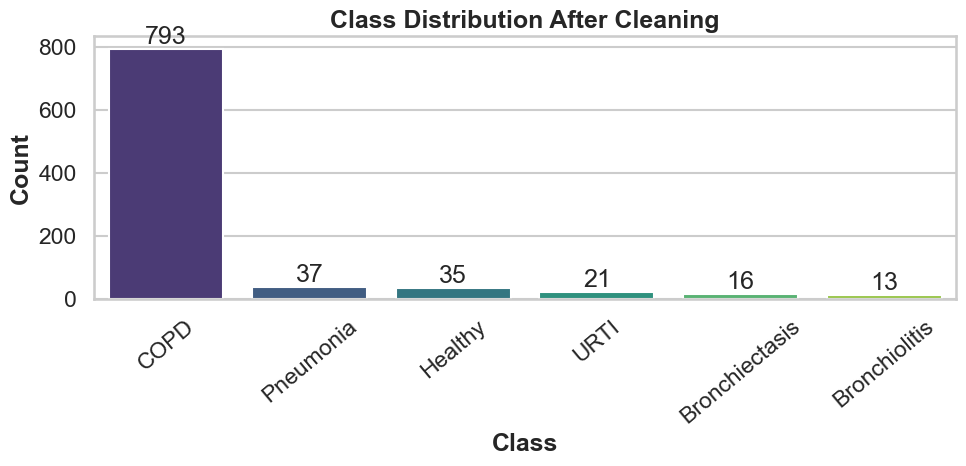

In [13]:
# Class Distribution (clean & professional)
class_counts = pd.Series(labels).value_counts().reset_index()
class_counts.columns = ["Class", "Count"]

plt.figure(figsize=(10,5))
ax = sns.barplot(data=class_counts, x="Class", y="Count", palette="viridis")

for i in ax.containers:
    ax.bar_label(i)

plt.title("Class Distribution After Cleaning")
plt.xticks(rotation=40)
plt.tight_layout()
plt.show()


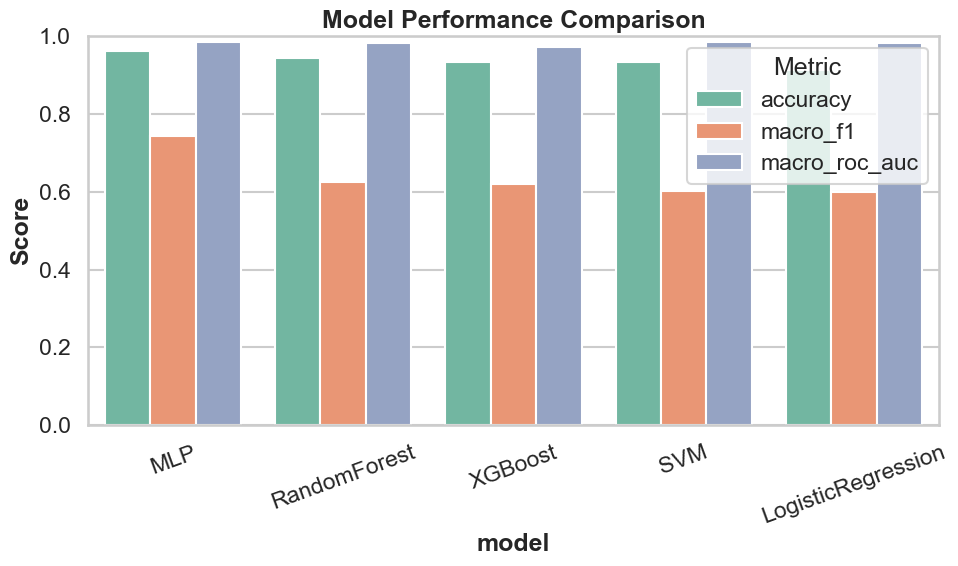

In [14]:
melted = summary_df.melt(id_vars="model",
                         value_vars=["accuracy", "macro_f1", "macro_roc_auc"],
                         var_name="Metric",
                         value_name="Score")

plt.figure(figsize=(10,6))
sns.barplot(data=melted, x="model", y="Score", hue="Metric", palette="Set2")

plt.title("Model Performance Comparison")
plt.ylim(0,1)
plt.legend(title="Metric")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


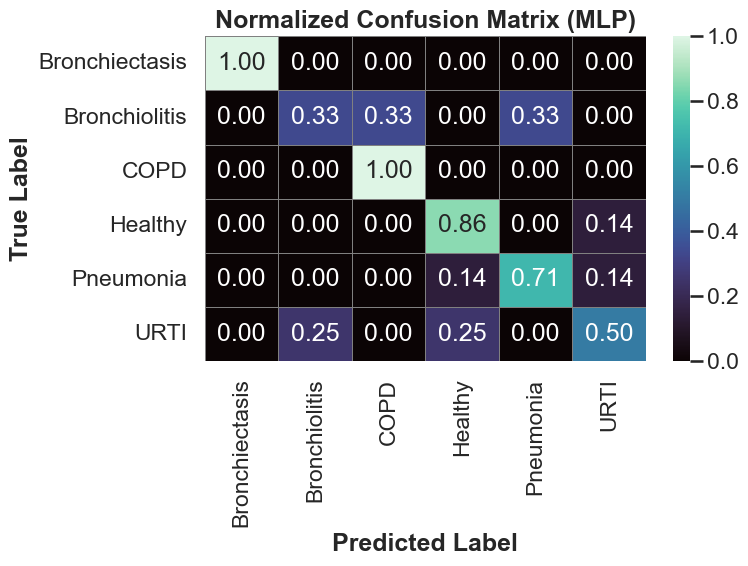

In [15]:
cm = confusion_matrix(y_test, best_res["y_pred"], normalize="true")

plt.figure(figsize=(8,6))
sns.heatmap(cm,
            annot=True,
            fmt=".2f",
            cmap="mako",
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            linewidths=0.5,
            linecolor='gray')

plt.title(f"Normalized Confusion Matrix ({best_name})")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


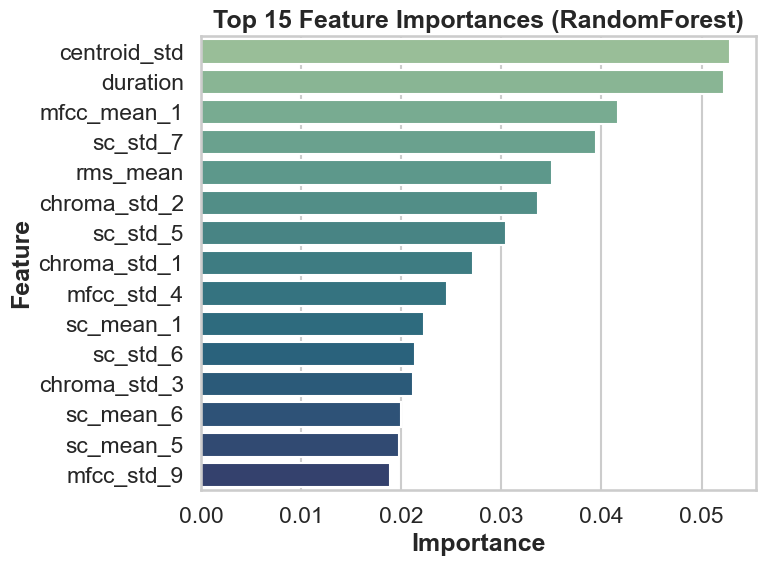

In [16]:
if "RandomForest" in results:
    rf = results["RandomForest"]["model"]
    if hasattr(rf, "feature_importances_"):
        importances = rf.feature_importances_
        feature_names = np.array(df_feat.columns[:-1])
        top_idx = np.argsort(importances)[-15:][::-1]

        fi_df = pd.DataFrame({
            "Feature": feature_names[top_idx],
            "Importance": importances[top_idx]
        })

        plt.figure(figsize=(8,6))
        sns.barplot(data=fi_df, y="Feature", x="Importance", palette="crest")
        plt.title("Top 15 Feature Importances (RandomForest)")
        plt.tight_layout()
        plt.show()


In [24]:
!jupyter nbconvert --to html --embed-images "Respiratory_Sound_Classification_Pipeline_reviewed.ipynb"


[NbConvertApp] Converting notebook Respiratory_Sound_Classification_Pipeline_reviewed.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 4 image(s).
[NbConvertApp] Writing 644719 bytes to Respiratory_Sound_Classification_Pipeline_reviewed.html
